In [1]:
import xarray as xr
from pathlib import Path
from xhistogram.xarray import histogram as xhist
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.patches as mpatches

# Plots for the Seminar
* Study case in April 1995-04-07 to 1995-04-22

## Load Data

In [2]:
# Particle paths 
hist_5 = xr.open_dataset("_hist_AT_N_seminar.nc").compute().histogram_lon_lat
# print(hist_5)

In [3]:
## SSH 
import warnings
warnings.filterwarnings("ignore", message=".*multiple fill values.*", module="xarray.conventions")

ssh = xr.open_dataset('/work/bk1450/b383184/Amazon/Mercator/data/variables_c/tracers/SSH_1993-01c.nc')
ssh = ssh.compute()
ssh

<xarray.Dataset> Size: 161MB
Dimensions:       (x: 1260, y: 499, time_counter: 31)
Coordinates:
  * x             (x) int32 5kB 2306 2307 2308 2309 2310 ... 3562 3563 3564 3565
  * y             (y) int32 2kB 1375 1376 1377 1378 1379 ... 1870 1871 1872 1873
  * time_counter  (time_counter) datetime64[ns] 248B 1993-01-01T12:00:00 ... ...
    nav_lon       (y, x) float32 3MB -95.0 -94.92 -94.83 ... 9.764 9.847 9.93
    nav_lat       (y, x) float32 3MB -9.95 -9.95 -9.95 ... 29.95 29.95 29.95
Data variables:
    sossheig      (time_counter, y, x) float64 156MB 0.1621 0.1623 ... nan nan

In [4]:
## Salinity
sal = xr.open_mfdataset('/work/bk1450/b383184/Amazon/Mercator/data/variables_c/tracers/S_*.nc').sel(
    time_counter=slice('1995-04-01','1995-05-30')).isel(deptht=0)
sal = sal.compute()

sal_ds = xr.Dataset(
    data_vars={
        'so': (('time','lat','lon'), sal.vosaline.data),
    },
    coords={
        'time':sal.time_counter.data,
        'lat':ssh.nav_lat.isel(x=0).data,
        'lon':ssh.nav_lon.isel(y=0).data,
    }
)
sal_ds
# sal5

<xarray.Dataset> Size: 151MB
Dimensions:  (time: 60, lat: 499, lon: 1260)
Coordinates:
  * time     (time) datetime64[ns] 480B 1995-04-01T12:00:00 ... 1995-05-30T12...
  * lat      (lat) float32 2kB -9.95 -9.868 -9.785 -9.703 ... 29.77 29.84 29.91
  * lon      (lon) float32 5kB -95.0 -94.92 -94.83 -94.75 ... 9.75 9.833 9.917
Data variables:
    so       (time, lat, lon) float32 151MB 35.27 35.27 35.28 ... nan nan nan

In [28]:
## salinity anomaly
sal_anom = xr.open_dataset('/work/bk1450/b383184/Amazon/Mercator/notebooks/seminar/Sal_d_anom.nc')
sal_anom

<xarray.Dataset> Size: 16GB
Dimensions:  (time: 6209, lat: 499, lon: 1260)
Coordinates:
  * time     (time) datetime64[ns] 50kB 1993-01-01T12:00:00 ... 2009-12-31T12...
  * lat      (lat) float32 2kB -9.95 -9.868 -9.785 -9.703 ... 29.77 29.84 29.91
  * lon      (lon) float32 5kB -95.0 -94.92 -94.83 -94.75 ... 9.75 9.833 9.917
    month    (time) int64 50kB ...
Data variables:
    so       (time, lat, lon) float32 16GB ...

In [5]:
## For UV calculation bring the U and V to the T points 
U = xr.open_mfdataset('/work/bk1450/b383184/Amazon/Mercator/data/variables_c/UVW/U*.nc').sel(
    time_counter=slice('1995-04-01','1995-05-30')).isel(deptht=0).rename({'vozocrtx': 'U'}).drop_vars('deptht')
U = U.compute()

V = xr.open_mfdataset('/work/bk1450/b383184/Amazon/Mercator/data/variables_c/UVW/V*.nc').sel(
    time_counter=slice('1995-04-01','1995-05-30')).isel(deptht=0).rename({'vomecrty':'V'}).drop_vars('deptht')
V = V.compute()

In [6]:
U_T = (U.U.shift(x=1) + U.U)*0.5

V_T = (V.V.shift(y=1) + V.V)*0.5

# UV = ((U.U**2 + V.V**2)**0.5).rename('UV')
# UV

In [7]:
UV = xr.Dataset(
    data_vars={
        'U': (('time','lat','lon'), U_T.data),
        'V': (('time','lat', 'lon'), V_T.data),
    },
    coords={
        'time':U_T.time_counter.data,
        'lat':ssh.nav_lat.isel(x=0).data,
        'lon':ssh.nav_lon.isel(y=0).data,
    }
)
UV['UV'] = (UV.U**2+UV.V**2)**0.5
UV

<xarray.Dataset> Size: 453MB
Dimensions:  (time: 60, lat: 499, lon: 1260)
Coordinates:
  * time     (time) datetime64[ns] 480B 1995-04-01T12:00:00 ... 1995-05-30T12...
  * lat      (lat) float32 2kB -9.95 -9.868 -9.785 -9.703 ... 29.77 29.84 29.91
  * lon      (lon) float32 5kB -95.0 -94.92 -94.83 -94.75 ... 9.75 9.833 9.917
Data variables:
    U        (time, lat, lon) float32 151MB nan -0.02551 -0.0008883 ... nan nan
    V        (time, lat, lon) float32 151MB nan nan nan nan ... nan nan nan nan
    UV       (time, lat, lon) float32 151MB nan nan nan nan ... nan nan nan nan

#### Relative Vorticity

In [8]:
import numpy as np
import xarray as xr

Re = 6.371e6  # Earth radius (m)

# Convert to radians
lat_rad = np.deg2rad(UV['lat'])
lon_rad = np.deg2rad(UV['lon'])

# Grid spacing in radians (1D)
dlat = lat_rad.diff('lat')
dlon = lon_rad.diff('lon')

# Broadcast metric factors to 2D (lat, lon)
cosphi = np.cos(lat_rad)
cosphi_2d = cosphi.broadcast_like(UV.isel(time=0)['U'])

# Compute derivatives using centered finite differences via diff
# dv/dlon: derivative along lon
dv_dlon = UV['V'].diff('lon') / dlon  # shape: (time, lat, lon-1)

# du/dlat: derivative along lat
du_dlat = UV['U'].diff('lat') / dlat  # shape: (time, lat-1, lon)

# Now place these on the interior grid with same dims as a trimmed UV
# For simplicity, we'll define an interior grid:
lat_i = UV['lat'].isel(lat=slice(1, -1))
lon_i = UV['lon'].isel(lon=slice(1, -1))

# Center dv/dlon in lon using averaging in lon, and trim lat edges
dv_dlon_c = 0.5 * (dv_dlon.isel(lon=slice(0, -1)) + dv_dlon.isel(lon=slice(1, None)))
dv_dlon_c = dv_dlon_c.isel(lat=slice(1, -1))  # interior lat

# Center du/dlat in lat using averaging in lat, and trim lon edges
du_dlat_c = 0.5 * (du_dlat.isel(lat=slice(0, -1)) + du_dlat.isel(lat=slice(1, None)))
du_dlat_c = du_dlat_c.isel(lon=slice(1, -1))  # interior lon

# Metric factors on interior grid
cosphi_i = np.cos(np.deg2rad(lat_i))
cosphi_i_2d = xr.DataArray(
    cosphi_i,
    dims=('lat',),
    coords={'lat': lat_i},
).broadcast_like(du_dlat_c.isel(time=0))

# Put everything together into vorticity (ζ)
zeta = (1.0 / (Re * cosphi_i_2d)) * dv_dlon_c - (1.0 / Re) * du_dlat_c
zeta = zeta.rename('vort')  # relative vorticity (1/s)
zeta

<xarray.DataArray 'vort' (lat: 496, lon: 1257, time: 60)> Size: 150MB
array([[[ 4.4464541e-06,  4.8466864e-06,  6.4689630e-06, ...,
          1.7562631e-06,  1.9807640e-06,  3.2574640e-06],
        [ 4.6664218e-06,  4.8772235e-06,  6.6915131e-06, ...,
          1.9248055e-06,  2.3356879e-06,  3.7000420e-06],
        [ 4.8100060e-06,  4.7893113e-06,  6.7377059e-06, ...,
          2.3238986e-06,  2.7059291e-06,  3.9076099e-06],
        ...,
        [ 1.5947276e-06,  1.0640802e-06,  1.4943469e-06, ...,
         -6.1269390e-08,  7.8547657e-09,  2.0633474e-06],
        [ 2.0152111e-06,  1.7583063e-06,  1.9779202e-06, ...,
          5.6921755e-07,  2.5088734e-06,  3.0098083e-06],
        [ 2.0748998e-06,  2.0467801e-06,  2.2242746e-06, ...,
          2.5725194e-06,  2.6193363e-06,  1.8461042e-06]],

       [[ 4.2892839e-06,  4.4164208e-06,  5.7001662e-06, ...,
          1.2154038e-06,  1.6102875e-06,  2.9840062e-06],
        [ 4.6336063e-06,  4.4919143e-06,  6.1777564e-06, ...,
          1.5626507e-06,  2.0664638e-06,  3.4862619e-06],
        [ 4.8812581e-06,  4.5294587e-06,  6.4674623e-06, ...,
          2.0961672e-06,  2.5593517e-06,  3.7732666e-06],
...
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan]],

       [[           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        ...,
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan]]],
      shape=(496, 1257, 60), dtype=float32)
Coordinates:
  * lat      (lat) float32 2kB -9.785 -9.703 -9.621 -9.539 ... 29.7 29.77 29.84
  * lon      (lon) float32 5kB -94.83 -94.75 -94.67 -94.58 ... 9.667 9.75 9.833
  * time     (time) datetime64[ns] 480B 1995-04-01T12:00:00 ... 1995-05-30T12...

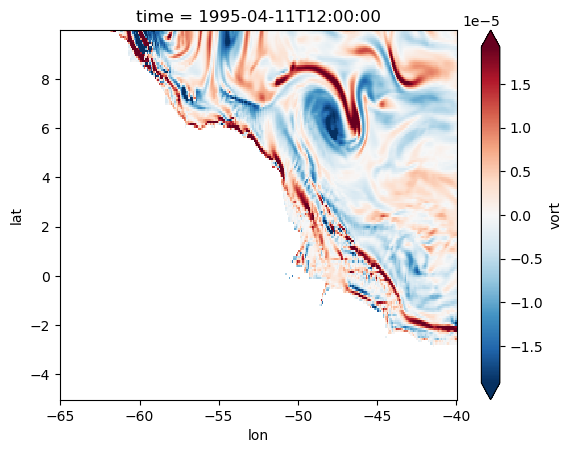

In [37]:
zeta.isel(time=10).sel(lon=slice(-65,-40),lat=slice(-5,10)).plot(robust=True,cmap='RdBu_r')

Maybe is worth it to check the optics properties and wavelength, maybe no, just in case

- optics
- optics = xr.open_dataset('/work/bk1450/b383184/Amazon/Atlantic/data/tracers/optics_cs.nc')
- optics = optics.compute()
- optics

## Extract selected dates

In [10]:
hist_cs = hist_5.sel(start_time=slice('1995-04-02','1995-04-27'))

* create an algorithm that calculates the tracer values 5 days and 10 days after the release or start_time

In [11]:
from datetime import datetime, timedelta

def find_next_X_days(days,iteration):
    t = datetime.strptime(str(hist_cs.start_time.values[iteration])[:10],"%Y-%m-%d")
    tx = str(t + timedelta(days=days))[:10]

    print('initial time', t)
    print(f'{days} days more', tx)
    return t,tx


In [12]:
for i in range(4):
    t,tx = find_next_X_days(10,i)

initial time 1995-04-02 00:00:00
10 days more 1995-04-12
initial time 1995-04-07 00:00:00
10 days more 1995-04-17
initial time 1995-04-12 00:00:00
10 days more 1995-04-22
initial time 1995-04-17 00:00:00
10 days more 1995-04-27


Text(0.5, 1.0, 'average 1995-04-17 to 1995-04-27')

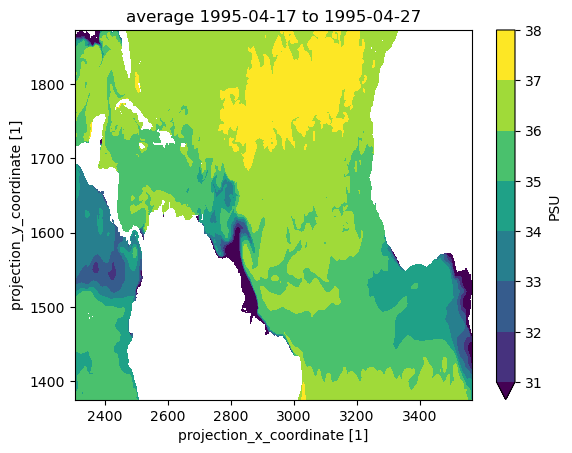

In [13]:
# sal = sal.drop_vars('depth')
sal.sel(time_counter=slice(t,tx)).mean(dim='time_counter').vosaline.rename('PSU').plot.contourf(robust=True)
plt.title(f'average {str(t)[:10]} to {tx}')

initial time 1995-04-02 00:00:00
10 days more 1995-04-12
initial time 1995-04-07 00:00:00
10 days more 1995-04-17
initial time 1995-04-12 00:00:00
10 days more 1995-04-22
initial time 1995-04-17 00:00:00
10 days more 1995-04-27
initial time 1995-04-22 00:00:00
10 days more 1995-05-02
initial time 1995-04-27 00:00:00
10 days more 1995-05-07


/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)


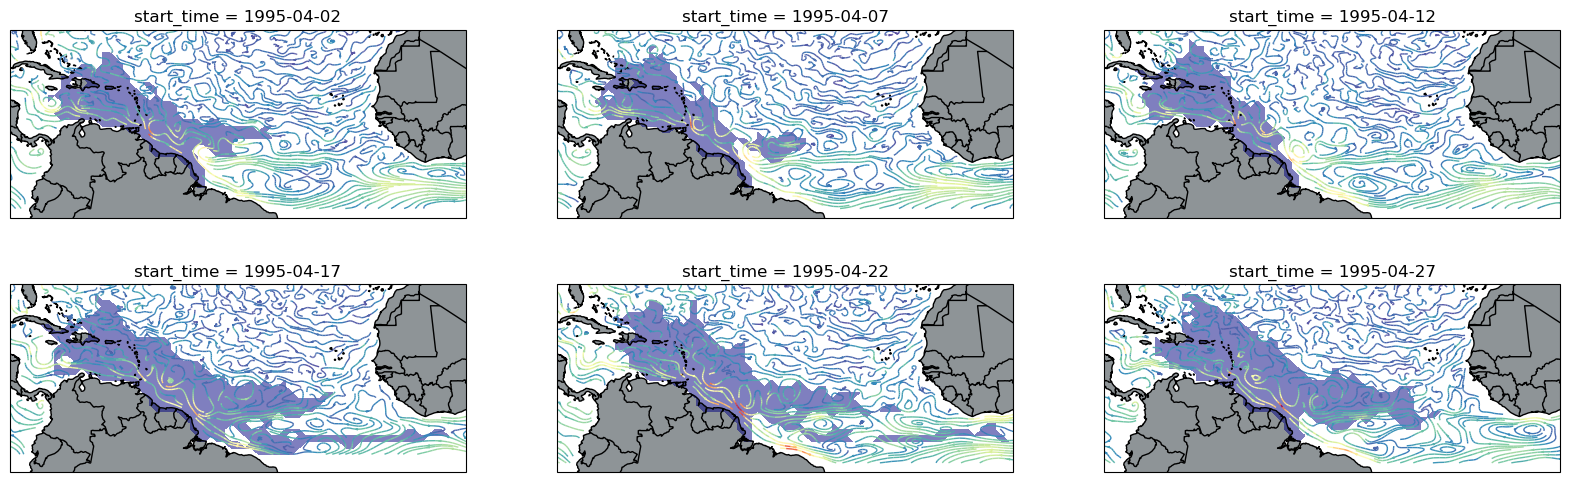

In [14]:
# 0) Precompute means once (lazy if dask-backed)
days =10
windows = [find_next_X_days(days, i) for i in range(6)]
U_mean = [UV.U.sel(time=slice(t0, t1)).mean('time') for t0, t1 in windows]
V_mean = [UV.V.sel(time=slice(t0, t1)).mean('time') for t0, t1 in windows]
UV_mean = [UV.UV.sel(time=slice(t0, t1)).mean('time') for t0, t1 in windows]

# 1) Decimate spatially before computing .values
s = 3  # stride; increase for more speed
x = UV.lon.isel(lon=slice(None, None, s)).values
y = UV.lat.isel(lat=slice(None, None, s)).values

fig, ax = plt.subplots(2, 3, figsize=(10*2,20*2), subplot_kw=dict(projection=ccrs.PlateCarree()))
ax = ax.ravel()

for i in range(0,6): 

    
    dat = hist_cs.isel(start_time=i).sum("obs")    
    np.log10(dat).plot.contourf(
                    x="lon", y="lat",
                    transform=ccrs.PlateCarree(), ax=ax[i],
                    add_colorbar=False,colors='#000080',alpha = 0.5, levels=[0,hist_5.max()]
                )
    u = U_mean[i].isel(lon=slice(None, None, s), lat=slice(None, None, s)).values
    v = V_mean[i].isel(lon=slice(None, None, s), lat=slice(None, None, s)).values
    uv = UV_mean[i].isel(lon=slice(None, None, s), lat=slice(None, None, s)).values

    # streamplot
    ax[i].streamplot(x, y, u, v, color=uv, transform=ccrs.PlateCarree(),
                 density=3, arrowsize=0.2, linewidth=1, cmap='Spectral_r')

    ax[i].coastlines()
    ax[i].set_extent([-85, 0, -6, 29], crs=ccrs.PlateCarree())
    ax[i].add_feature(cf.BORDERS)
    ax[i].add_feature(cf.LAND, facecolor='#8e9497ff', zorder=0)

fig.subplots_adjust(wspace=0.2, hspace=-0.91)

# plt.savefig(f'Stream_plot_cs_{days}_days_colors.png',dpi=300, bbox_inches='tight')


initial time 1995-04-02 00:00:00
5 days more 1995-04-07
initial time 1995-04-07 00:00:00
5 days more 1995-04-12
initial time 1995-04-12 00:00:00
5 days more 1995-04-17
initial time 1995-04-17 00:00:00
5 days more 1995-04-22
initial time 1995-04-22 00:00:00
5 days more 1995-04-27
initial time 1995-04-27 00:00:00
5 days more 1995-05-02


/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)


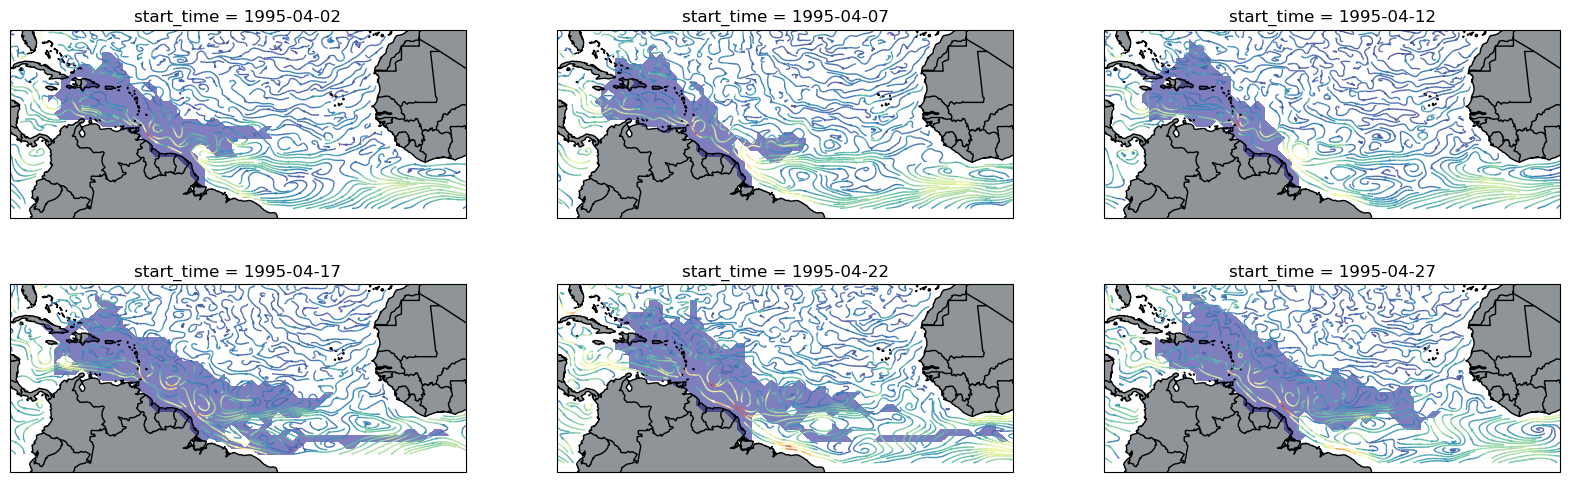

In [15]:
days = 5
windows = [find_next_X_days(days, i) for i in range(6)]
U_mean = [UV.U.sel(time=slice(t0, t1)).mean('time') for t0, t1 in windows]
V_mean = [UV.V.sel(time=slice(t0, t1)).mean('time') for t0, t1 in windows]
UV_mean = [UV.UV.sel(time=slice(t0, t1)).mean('time') for t0, t1 in windows]

# 1) Decimate spatially before computing .values
s = 3  # stride; increase for more speed
x = UV.lon.isel(lon=slice(None, None, s)).values
y = UV.lat.isel(lat=slice(None, None, s)).values

fig, ax = plt.subplots(2, 3, figsize=(10*2,20*2), subplot_kw=dict(projection=ccrs.PlateCarree()))
ax = ax.ravel()

for i in range(0,6): 
    
    dat = hist_cs.isel(start_time=i).sum("obs")    
    np.log10(dat).plot.contourf(
                    x="lon", y="lat",
                    transform=ccrs.PlateCarree(), ax=ax[i],
                    add_colorbar=False,colors='#000080',alpha = 0.5, levels=[0,hist_5.max()]
                )
    u = U_mean[i].isel(lon=slice(None, None, s), lat=slice(None, None, s)).values
    v = V_mean[i].isel(lon=slice(None, None, s), lat=slice(None, None, s)).values
    uv = UV_mean[i].isel(lon=slice(None, None, s), lat=slice(None, None, s)).values

    # streamplot
    ax[i].streamplot(x, y, u, v, color=uv, transform=ccrs.PlateCarree(),
                 density=3, arrowsize=0.2, linewidth=1, cmap='Spectral_r')

    ax[i].coastlines()
    ax[i].set_extent([-85, 0, -6, 29], crs=ccrs.PlateCarree())
    ax[i].add_feature(cf.BORDERS)
    ax[i].add_feature(cf.LAND, facecolor='#8e9497ff', zorder=0)

fig.subplots_adjust(wspace=0.2, hspace=-0.91)

# plt.savefig(f'Stream_plot_cs_{days}_days_colors.png',dpi=300, bbox_inches='tight')

### Tracers plotter

In [16]:
def plotting_tracers(days,tracer,cmap,lines_color,lines_density=None,lw=None):
        #lines_density default = 3
        #provide a tracer that is a data array
    if lines_density is None:
        lines_density=3

    if lw  is None:
        lw = 0.5
        
    days = days
    
    windows = [find_next_X_days(days, i) for i in range(6)]
    U_mean = [UV.U.sel(time=slice(t0, t1)).mean('time') for t0, t1 in windows]
    V_mean = [UV.V.sel(time=slice(t0, t1)).mean('time') for t0, t1 in windows]
    tracer_mean = [tracer.sel(time=slice(t0,t1)).mean(dim='time') for t0, t1 in windows]
    
    # 1) Decimate spatially before computing .values
    s = 3  # stride; increase for more speed
    x = UV.lon.isel(lon=slice(None, None, s)).values
    y = UV.lat.isel(lat=slice(None, None, s)).values
    lon = tracer.lon.values
    lat = tracer.lat.values
    
    fig, ax = plt.subplots(2, 3, figsize=(10*2,20*2), subplot_kw=dict(projection=ccrs.PlateCarree()))
    ax = ax.ravel()
    
    for i in range(0,6): 
    
        u = U_mean[i].isel(lon=slice(None, None, s), lat=slice(None, None, s)).values
        v = V_mean[i].isel(lon=slice(None, None, s), lat=slice(None, None, s)).values
        ss = tracer_mean[i].values
        
        #robust 
        p2, p98 = np.nanpercentile(ss, [2, 98])
        
        ax[i].pcolormesh(lon, lat, ss,
                   vmin=p2, vmax=p98, cmap=cmap, shading='auto')
        
        # streamplot
        ax[i].streamplot(x, y, u, v, color=lines_color, transform=ccrs.PlateCarree(),
                     density=lines_density, arrowsize=0.2, linewidth=lw)
    
        ax[i].coastlines()
        ax[i].set_extent([-85, 0, -6, 29], crs=ccrs.PlateCarree())
        ax[i].add_feature(cf.BORDERS)
        ax[i].add_feature(cf.LAND, facecolor='#8e9497ff', zorder=0)
        t = str(windows[i][0])[:10]
        
        ax[i].set_title(f'start_time = {t}')
        
    fig.subplots_adjust(wspace=0.2, hspace=-0.91)
    # plt.savefig(f'{tracer}_cs_{days}_days_colors.png',dpi=300, bbox_inches='tight')


## Salinity

initial time 1995-04-02 00:00:00
10 days more 1995-04-12
initial time 1995-04-07 00:00:00
10 days more 1995-04-17
initial time 1995-04-12 00:00:00
10 days more 1995-04-22
initial time 1995-04-17 00:00:00
10 days more 1995-04-27
initial time 1995-04-22 00:00:00
10 days more 1995-05-02
initial time 1995-04-27 00:00:00
10 days more 1995-05-07


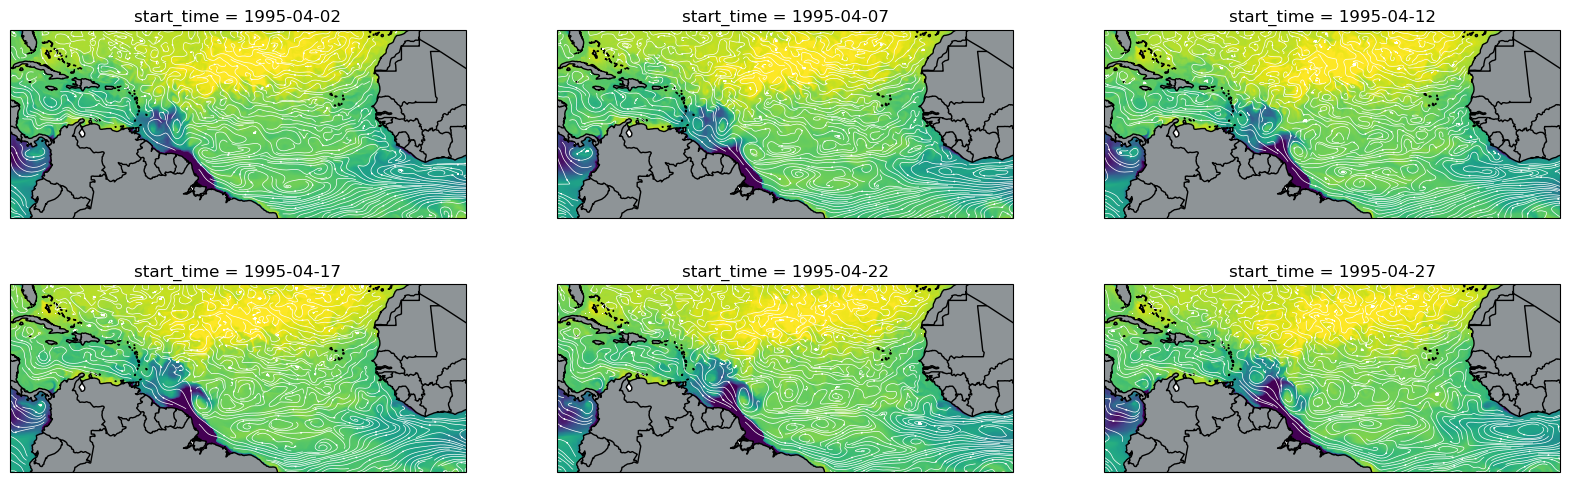

In [21]:
plotting_tracers(days=10,tracer=sal_ds.so,cmap='viridis',lines_color='w',lines_density=4)
plt.savefig(f'Salinity_cs_10_days_colors.png',dpi=300, bbox_inches='tight')

initial time 1995-04-02 00:00:00
5 days more 1995-04-07
initial time 1995-04-07 00:00:00
5 days more 1995-04-12
initial time 1995-04-12 00:00:00
5 days more 1995-04-17
initial time 1995-04-17 00:00:00
5 days more 1995-04-22
initial time 1995-04-22 00:00:00
5 days more 1995-04-27
initial time 1995-04-27 00:00:00
5 days more 1995-05-02


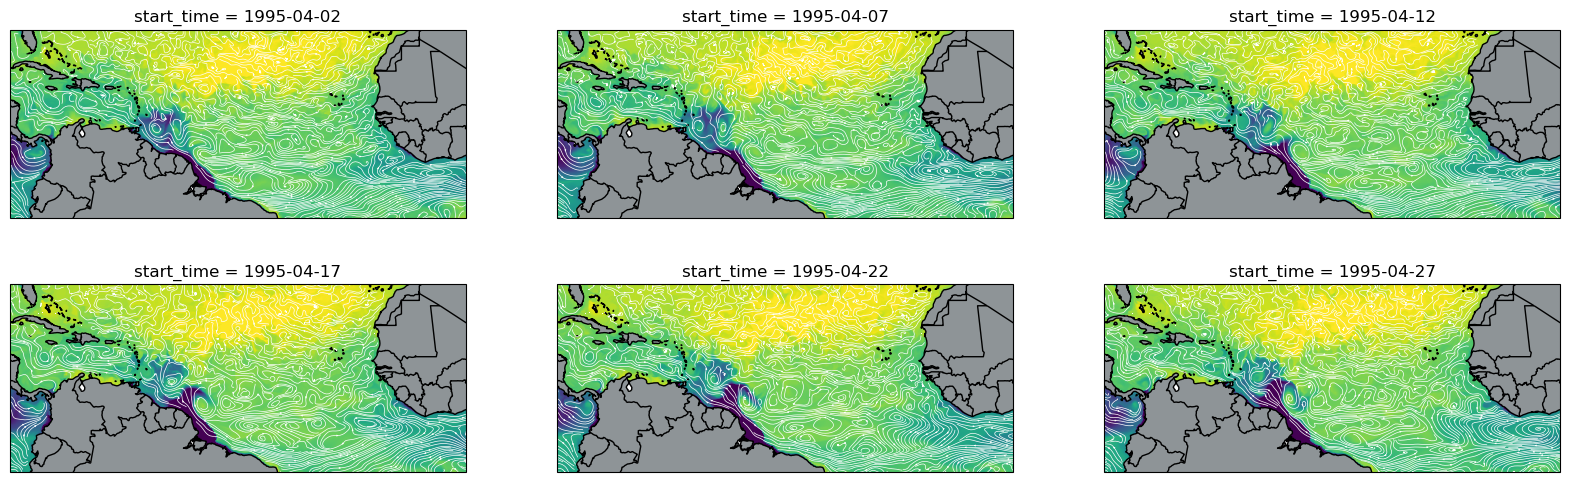

In [35]:
plotting_tracers(days=5,tracer=sal_ds.so,cmap='viridis',lines_color='w',lines_density=6)
# plt.savefig(f'Salinity_cs_5_days_colors.png',dpi=300, bbox_inches='tight')

#### Salinity anom

initial time 1995-04-02 00:00:00
10 days more 1995-04-12
initial time 1995-04-07 00:00:00
10 days more 1995-04-17
initial time 1995-04-12 00:00:00
10 days more 1995-04-22
initial time 1995-04-17 00:00:00
10 days more 1995-04-27
initial time 1995-04-22 00:00:00
10 days more 1995-05-02
initial time 1995-04-27 00:00:00
10 days more 1995-05-07


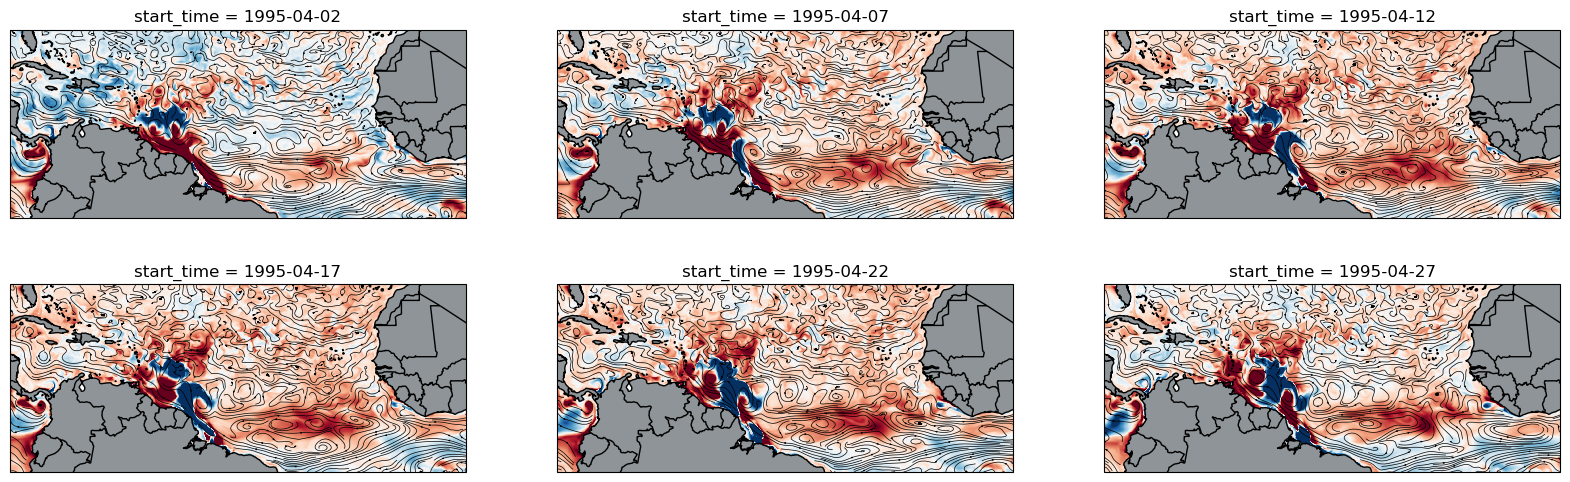

In [39]:
# sal_anom
plotting_tracers(days=10,tracer=sal_anom.so,cmap='RdBu_r',lines_color='k',lines_density=4)
plt.savefig(f'Sal_anom_cs_10_days_colors.png',dpi=300, bbox_inches='tight')

## UV

initial time 1995-04-02 00:00:00
5 days more 1995-04-07
initial time 1995-04-07 00:00:00
5 days more 1995-04-12
initial time 1995-04-12 00:00:00
5 days more 1995-04-17
initial time 1995-04-17 00:00:00
5 days more 1995-04-22
initial time 1995-04-22 00:00:00
5 days more 1995-04-27
initial time 1995-04-27 00:00:00
5 days more 1995-05-02


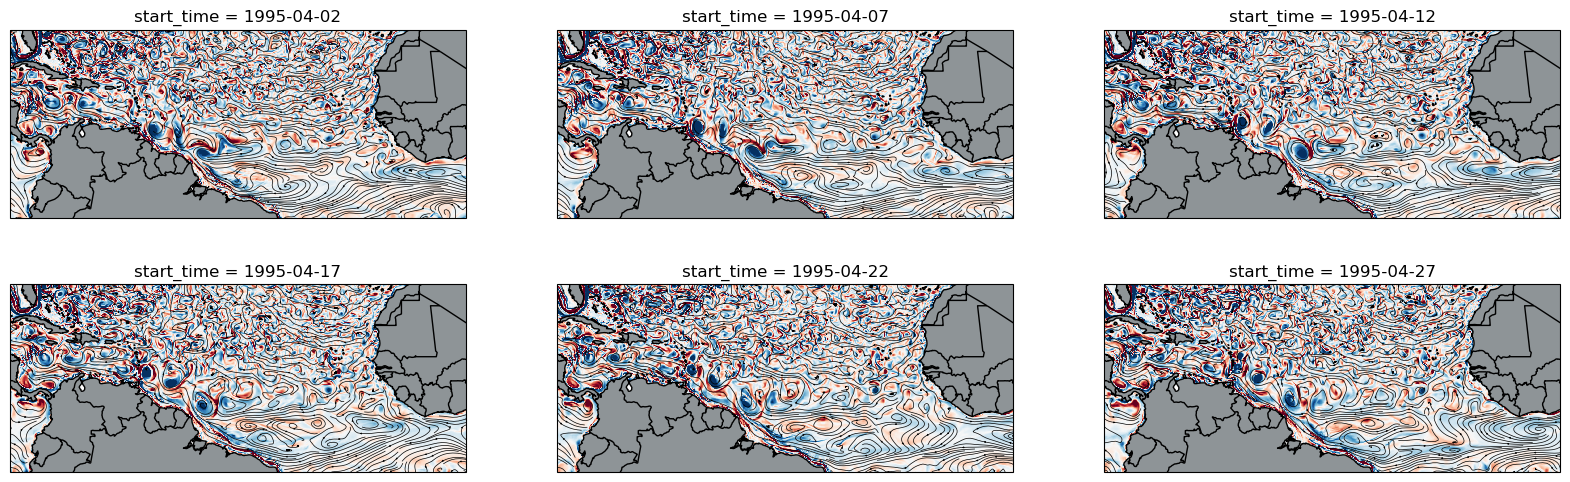

In [19]:
plotting_tracers(days=5,tracer=zeta,cmap='viridis',lines_color='k',lines_density=4)
# plt.savefig(f'Vorticity_cs_5_days_colors.png',dpi=300, bbox_inches='tight')

initial time 1995-04-02 00:00:00
10 days more 1995-04-12
initial time 1995-04-07 00:00:00
10 days more 1995-04-17
initial time 1995-04-12 00:00:00
10 days more 1995-04-22
initial time 1995-04-17 00:00:00
10 days more 1995-04-27
initial time 1995-04-22 00:00:00
10 days more 1995-05-02
initial time 1995-04-27 00:00:00
10 days more 1995-05-07


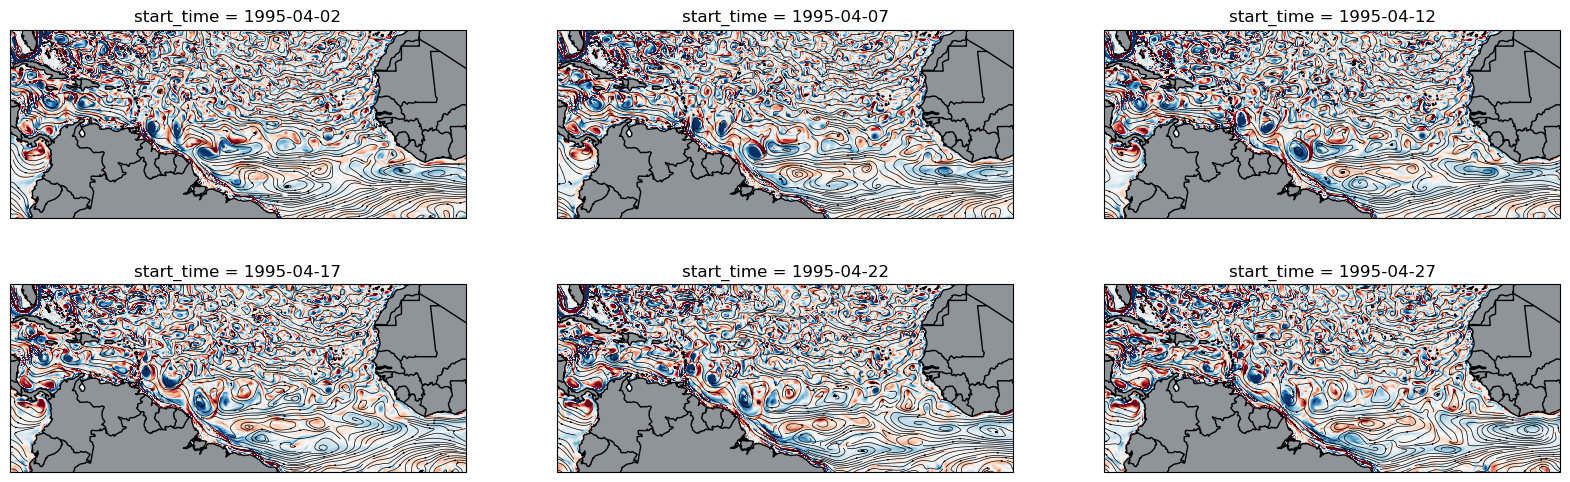

In [32]:
plotting_tracers(days=10,tracer=zeta,cmap='RdBu_r',lines_color='k',lines_density=4)
plt.savefig(f'Vorticity_cs_10_days_colors.png',dpi=300, bbox_inches='tight')

## KD90 

* Try KD490 anomalies
* Salinity anonmalies -- done
* SZD anomalies 